## Evaluator-Optimizer

## Definition of Evaluator-Optimizer

In the **evaluator-optimizer workflow**, one LLM generates a response while another LLM evaluates the response and provides feedback. The generator then uses this feedback to improve the response through an iterative loop.

## When to Use Evaluator-Optimizer

This workflow is particularly effective when:

- There are **clear evaluation criteria** for judging the output.
- The output can be **measurably improved through iterative refinement**.
- Feedback can be clearly expressed and used by the generator.
- The task benefits from repeated **generation → evaluation → improvement** cycles.

Examples include writing, code generation, summarization, content refinement, and other tasks where quality can improve through feedback.

## How Evaluator-Optimizer Works with LangGraph

1. **Generate:** The Generator LLM creates an initial response based on the input.

2. **Evaluate:** The Evaluator LLM reviews the generated response according to predefined criteria.

3. **Provide Feedback:** If the response does not meet the required criteria, the evaluator provides feedback describing what should be improved.

4. **Refine:** The Generator receives the evaluator's feedback and generates an improved response.

5. **Repeat:** The improved response is evaluated again. This loop continues until the response satisfies the evaluation criteria.

6. **Return the Output:** Once the response passes the evaluation, the workflow returns it as the final output.

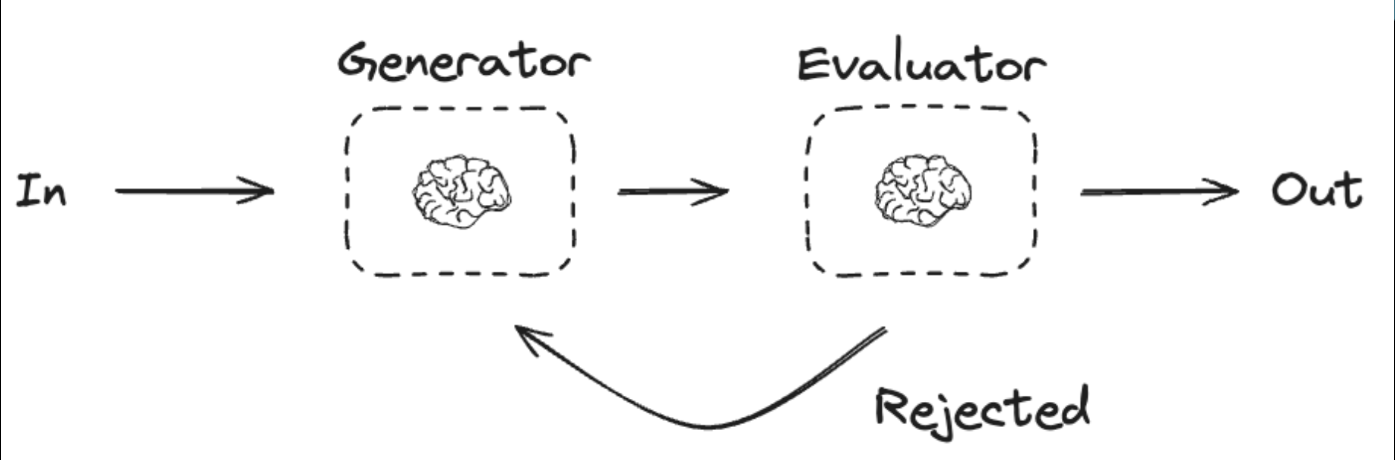

## Benefits of Evaluator-Optimizer

- **Iterative Improvement:** Allows the generated output to be refined through multiple evaluation cycles.

- **Better Quality:** Evaluation and feedback can help identify weaknesses and improve the final response.

- **Clear Quality Control:** Predefined evaluation criteria provide a structured way to assess generated outputs.

- **Feedback-Driven Refinement:** The generator can use specific feedback to correct and improve its response.

- **Flexible Workflow:** The evaluator can be designed for different criteria such as accuracy, clarity, style, or completeness.

- **Useful for Complex Tasks:** Works well for tasks where a single generation step may not produce a sufficiently polished result.

## Problem Statement

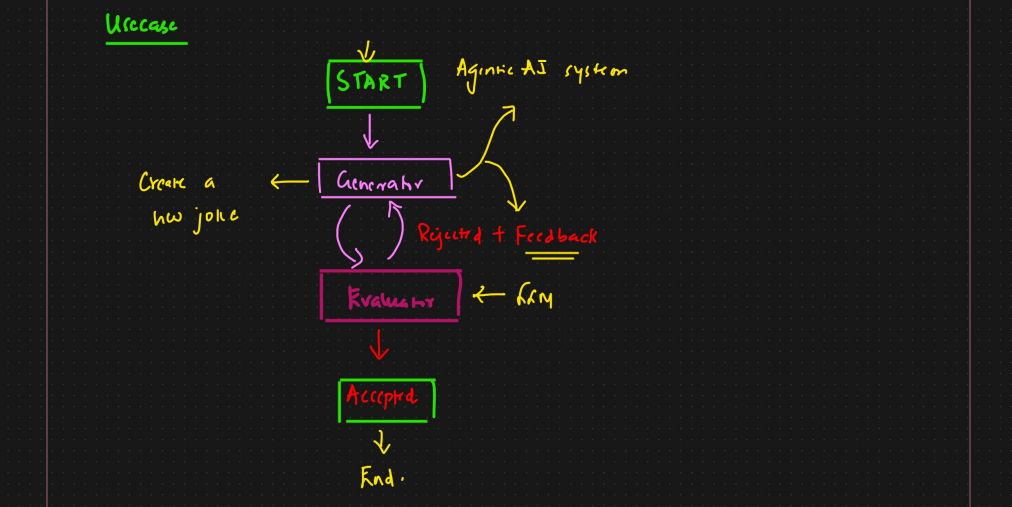

## Solution

### Setting Up the Chat Model

In [2]:
### Importing Required Libraries
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    max_tokens=500
)

result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 13, 'total_tokens': 23, 'completion_time': 0.019172909, 'completion_tokens_details': None, 'prompt_time': 0.000599059, 'prompt_tokens_details': None, 'queue_time': 0.0469059, 'total_time': 0.019771968}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_424cb89518', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fd31-7c80-7fe1-af24-a5ae3f61a61c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 10, 'total_tokens': 23})

### Defining the Evaluation Schema

In [4]:
from typing import Annotated, List
import operator
from typing_extensions import Literal, TypedDict
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage

# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )

# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)

### Defining the Graph State

In [5]:
### Creating the Graph State
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

### Defining the Generator and Evaluator Nodes

In [6]:
### Creating the Joke Generator Node
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


### Creating the Joke Evaluator Node
def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"

### Building the Evaluator-Optimizer Workflow

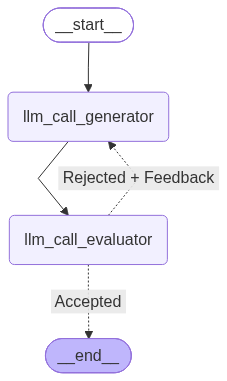

In [7]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

### Creating the StateGraph
optimizer_builder = StateGraph(State)

### Adding the Graph Nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

### Adding the Graph Edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

### Compiling the Workflow
optimizer_workflow = optimizer_builder.compile()
### Visualizing the Workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

### Running the Evaluator-Optimizer Workflow

#### Generating the Initial Joke

In [9]:
state = optimizer_workflow.invoke({"topic": "B. Tech"})
print(state["joke"])

A B.Tech student walks into a bar and asks the bartender, "Do you have any practical experience?"

The bartender looks him up and down, deadpan, and says, "No. But I can show you the diagram of where the beer *should* be pouring."


#### Generating the Revised Joke

In [8]:
state = optimizer_workflow.invoke({"topic": "iPhone and Samsung"})
print(state["joke"])

Here is a revised joke that addresses the feedback by clarifying the premise, making the punchline logically consistent with the star/Samsung setup, and avoiding the confusing "humor app" analogy.

**The Setup:**
I told my iPhone a joke about why my Samsung phone was so popular in space.

**The Punchline:**
My iPhone looked at me and said, "That’s not a joke, that’s just a **Galaxy**. You’re out of your element."

***

**Why this works better:**
1.  **Clear Premise:** It simply states you told the iPhone a joke *about* the Samsung phone.
2.  **Strong Connection:** The punchline directly ties "Samsung" to "Galaxy" (which is both a Samsung phone model and a celestial body), resolving the "star-related" confusion.
3.  **Logical Punchline:** The iPhone’s response ("You’re out of your element") is a clever double entendre:
    *   It’s a common idiom meaning someone is in the wrong situation.
    *   It’s a literal joke because iPhones (and Androids) are terrestrial tech, while "Galaxy" imp